# Comparing Unsupervised Learning Methods for Student Classification Using Synthetic AP Data

**Course:** AAI201 Machine Learning  
**Student Name:** Meghan Oster  
**Date:** May 2026  

## Project Overview

This project compares several unsupervised machine learning methods for classifying students using synthetically generated AP-like data. The goal is to determine whether different clustering approaches produce meaningful and interpretable student groups based on AP participation and performance patterns.

The methods compared in this notebook include:

- K-Means clustering
- Hierarchical clustering
- DBSCAN
- Gaussian Mixture Models (GMM)

PCA is used for visualization, but the clustering models are fit using the full feature space unless otherwise noted.

## 1. Problem Statement

Classifying students based on academic behavior can help researchers better understand learning patterns and student pathways. In prior work, methods such as PCA combined with latent class analysis have been used to group students based on AP course-taking and exam performance.

However, those approaches may not fully capture more complex or non-linear relationships in the data. This project explores whether alternative unsupervised machine learning methods can produce distinct and interpretable student classifications using synthetic AP data.

Because this is an unsupervised learning problem, the goal is not to predict a known outcome. Instead, the goal is to compare clustering methods and evaluate whether the resulting student groups are meaningful, stable, and interpretable.

## 2. Dataset Description and Data Generation Plan

This project uses a synthetically generated dataset designed to resemble AP student participation and exam performance data.

The dataset will include student-level features such as:

- Number of AP courses taken
- Number of STEM AP courses
- Number of humanities AP courses
- Average AP exam score
- Variation in exam scores
- Participation intensity

The synthetic data generation process will be designed intentionally. Rather than generating random values with no structure, the data will be created from several underlying student profiles. These profiles represent different patterns of AP participation, such as high-intensity STEM students, humanities-focused students, balanced students, and lower-participation students.

This design helps create realistic structure for clustering models to detect while avoiding the use of private or sensitive student data.

### 2.1 Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Dimensionality reduction
from sklearn.decomposition import PCA

# Clustering models
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Hierarchical clustering visualization
from scipy.cluster.hierarchy import dendrogram, linkage

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 2.2 Generate Synthetic AP Dataset

This section creates the synthetic student dataset.

In [2]:
def generate_ap_student_data(n_students=3000, random_state=42):
    np.random.seed(random_state)
    
    data = []
    
    for _ in range(n_students):
        
        # Randomly assign a "true" student type
        student_type = np.random.choice([
            "high_stem",
            "balanced",
            "humanities",
            "low_participation"
        ], p=[0.25, 0.30, 0.20, 0.25])
        
        # Generate features based on type
        if student_type == "high_stem":
            num_ap = np.random.randint(5, 9)
            stem = np.random.randint(int(num_ap * 0.6), num_ap + 1)
            humanities = num_ap - stem
            avg_score = np.random.normal(4.3, 0.3)
            score_var = np.random.uniform(0.2, 0.8)
        
        elif student_type == "balanced":
            num_ap = np.random.randint(3, 7)
            stem = np.random.randint(1, num_ap)
            humanities = num_ap - stem
            avg_score = np.random.normal(3.5, 0.4)
            score_var = np.random.uniform(0.3, 1.0)
        
        elif student_type == "humanities":
            num_ap = np.random.randint(3, 7)
            humanities = np.random.randint(int(num_ap * 0.6), num_ap + 1)
            stem = num_ap - humanities
            avg_score = np.random.normal(3.4, 0.4)
            score_var = np.random.uniform(0.3, 1.0)
        
        else:  # low_participation
            num_ap = np.random.randint(0, 3)
            stem = np.random.randint(0, num_ap + 1)
            humanities = num_ap - stem
            avg_score = np.random.normal(2.6, 0.5)
            score_var = np.random.uniform(0.5, 1.5)
        
        # Clip values to realistic bounds
        avg_score = np.clip(avg_score, 1, 5)
        
        # Derived feature
        participation_intensity = num_ap * avg_score
        
        data.append([
            num_ap,
            stem,
            humanities,
            avg_score,
            score_var,
            participation_intensity
        ])
    
    columns = [
        "num_ap_courses",
        "stem_courses",
        "humanities_courses",
        "avg_exam_score",
        "score_variance",
        "participation_intensity"
    ]
    
    return pd.DataFrame(data, columns=columns)



### 2.3 Initial Data Review

After generating the dataset, this section inspects the data structure and check for missing or unusual values.

In [3]:
df = generate_ap_student_data(n_students=3000, random_state=42)

df.head()

,num_ap_courses,stem_courses,humanities_courses,avg_exam_score,score_variance,participation_intensity
0,3,1,2,3.759075,0.409213,11.277226
1,7,6,1,4.756909,0.719706,33.298363
2,6,1,5,3.212210,0.427277,19.273261
3,8,5,3,4.462768,0.514854,35.702144
4,3,1,2,3.094868,0.504501,9.284603


In [4]:
df.describe()

,num_ap_courses,stem_courses,humanities_courses,avg_exam_score,score_variance,participation_intensity
count,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,4.21400,2.339333,1.874667,3.487728,0.692800,15.853406
std,2.23589,2.029998,1.490089,0.716849,0.283931,9.959062
min,0.00000,0.000000,0.000000,1.039728,0.202606,0.000000
25%,3.00000,1.000000,1.000000,3.021948,0.476207,9.077434
50%,5.00000,2.000000,2.000000,3.495848,0.668774,15.628716
75%,6.00000,4.000000,3.000000,4.042354,0.860642,22.442716
max,8.00000,8.000000,6.000000,5.000000,1.496297,40.000000


In [5]:
df.corr(numeric_only=True)

,num_ap_courses,stem_courses,humanities_courses,avg_exam_score,score_variance,participation_intensity
num_ap_courses,1.000000,0.760074,0.465033,0.721555,-0.546695,0.966880
stem_courses,0.760074,1.000000,-0.221836,0.674923,-0.430256,0.813609
humanities_courses,0.465033,-0.221836,1.000000,0.163229,-0.234167,0.342404
avg_exam_score,0.721555,0.674923,0.163229,1.000000,-0.495323,0.835619
score_variance,-0.546695,-0.430256,-0.234167,-0.495323,1.000000,-0.540219
participation_intensity,0.966880,0.813609,0.342404,0.835619,-0.540219,1.000000


In [6]:
# Should always be true
(df["stem_courses"] + df["humanities_courses"] == df["num_ap_courses"]).all()

True

In [7]:
df["num_ap_courses"].value_counts().sort_index()

num_ap_courses
0    244
1    222
2    225
3    389
4    387
5    550
6    587
7    185
8    211
Name: count, dtype: int64

### 2.4 Exploratory Data Analysis

This section summarize the synthetic data before modeling.

Visuals:

- Distribution of AP courses taken
- Distribution of average exam scores
- Correlation matrix of features

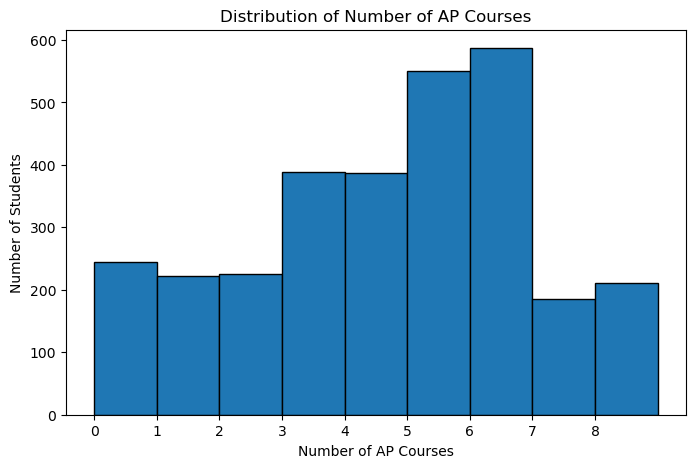

In [8]:
#Plot distribution of Number of APs 
plt.figure(figsize=(8, 5))
plt.hist(df['num_ap_courses'], bins=range(0, 10), edgecolor='black')
plt.title('Distribution of Number of AP Courses')
plt.xlabel('Number of AP Courses')
plt.ylabel('Number of Students')
plt.xticks(range(0, 9))
plt.show()

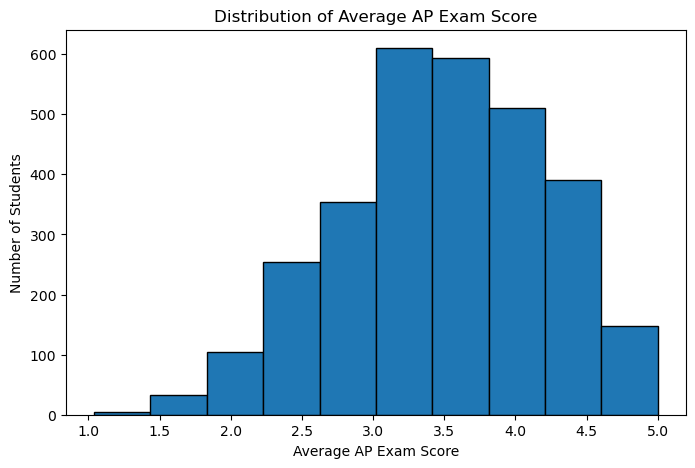

In [9]:
#Plot distribution of average exam scores

plt.figure(figsize=(8, 5))
plt.hist(df['avg_exam_score'], bins=10, edgecolor='black')
plt.title('Distribution of Average AP Exam Score')
plt.xlabel('Average AP Exam Score')
plt.ylabel('Number of Students')
plt.show()

In [10]:
##Correlation matrix

corr = df.corr(numeric_only=True)
corr

,num_ap_courses,stem_courses,humanities_courses,avg_exam_score,score_variance,participation_intensity
num_ap_courses,1.000000,0.760074,0.465033,0.721555,-0.546695,0.966880
stem_courses,0.760074,1.000000,-0.221836,0.674923,-0.430256,0.813609
humanities_courses,0.465033,-0.221836,1.000000,0.163229,-0.234167,0.342404
avg_exam_score,0.721555,0.674923,0.163229,1.000000,-0.495323,0.835619
score_variance,-0.546695,-0.430256,-0.234167,-0.495323,1.000000,-0.540219
participation_intensity,0.966880,0.813609,0.342404,0.835619,-0.540219,1.000000


## 3. Preprocessing

Because clustering methods are distance-based or sensitive to feature scale, the numeric features are standardized before modeling.

The clustering models are fitted using the standardized full feature space. PCA will be used mainly for visualization, not as the primary basis for conclusions unless explicitly stated.

In [11]:
#Select numeric features for clustering

feature_cols = [
    'num_ap_courses',
    'stem_courses',
    'humanities_courses',
    'avg_exam_score',
    'score_variance',
    'participation_intensity'
]

X = df[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.head()

,num_ap_courses,stem_courses,humanities_courses,avg_exam_score,score_variance,participation_intensity
0,-0.543051,-0.659881,0.084125,0.378591,-0.998955,-0.459576
1,1.246244,1.803586,-0.587087,1.770795,0.094777,1.751959
2,0.798920,-0.659881,2.097764,-0.384410,-0.935321,0.343449
3,1.693568,1.310893,0.755338,1.360402,-0.626828,1.993365
4,-0.543051,-0.659881,0.084125,-0.548130,-0.663295,-0.659690


## 4. PCA for Visualization

PCA will reduce the standardized feature space to two dimensions for visualization. This helps display the clusters in a simple plot.

Important note: PCA plots are used for visual interpretation only. Clustering results should not be judged only by the two-dimensional PCA view because some information is lost when reducing dimensions.

In [12]:
# Fit PCA for visualization

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total variance explained:', pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.63937238 0.20201673]
Total variance explained: 0.8413891101580764


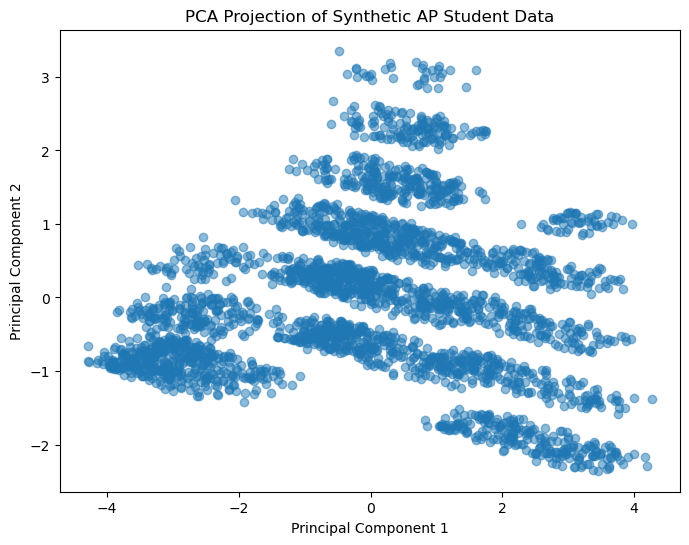

In [13]:
#Plot PCA projection without cluster labels

plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
plt.title('PCA Projection of Synthetic AP Student Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## 5. Model 1: K-Means Clustering

K-Means is a common baseline clustering method. It assigns students to a fixed number of clusters by minimizing within-cluster distance.

Because K-Means requires the number of clusters to be chosen in advance, this section compares several values of k and evaluates them using silhouette score and other clustering metrics.

In [14]:
#Tune K-Means across several k values

k_values = range(2, 7)
kmeans_results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)

    kmeans_results.append({
         'model': 'KMeans',
         'k': k,
         'silhouette_score': sil,
         'davies_bouldin_score': db,
         'calinski_harabasz_score': ch
     })

kmeans_results_df = pd.DataFrame(kmeans_results)
kmeans_results_df

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,model,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,KMeans,2,0.352569,1.046182,2246.755654
1,KMeans,3,0.368485,1.009071,2601.009186
2,KMeans,4,0.313272,1.160293,2254.487556
3,KMeans,5,0.287948,1.327667,1976.450903
4,KMeans,6,0.268489,1.334377,1826.911600


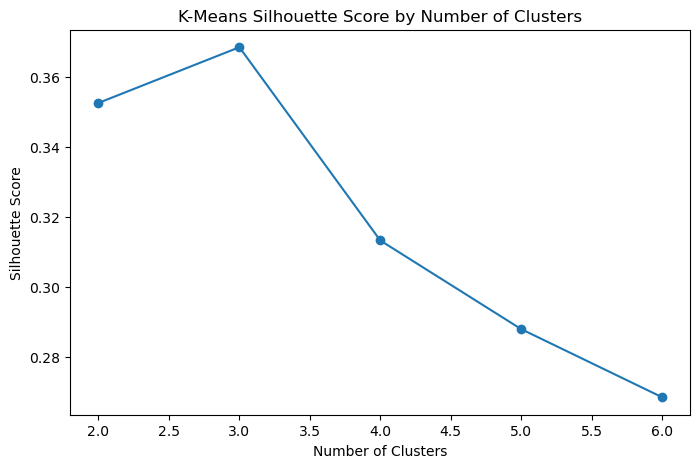

In [15]:
# Plot K-Means silhouette scores

plt.figure(figsize=(8, 5))
plt.plot(kmeans_results_df['k'], kmeans_results_df['silhouette_score'], marker='o')
plt.title('K-Means Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [16]:
#Fit final K-Means model

best_k = kmeans_results_df.sort_values('silhouette_score', ascending=False).iloc[0]['k']
best_k = int(best_k)

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df['kmeans_cluster'] = kmeans_final.fit_predict(X_scaled)

best_k

#sort clusters by num_ap_courses
cluster_order = df.groupby('kmeans_cluster')['num_ap_courses'].mean().sort_values().index
mapping = {old: new for new, old in enumerate(cluster_order)}

df['kmeans_cluster_ordered'] = df['kmeans_cluster'].map(mapping)

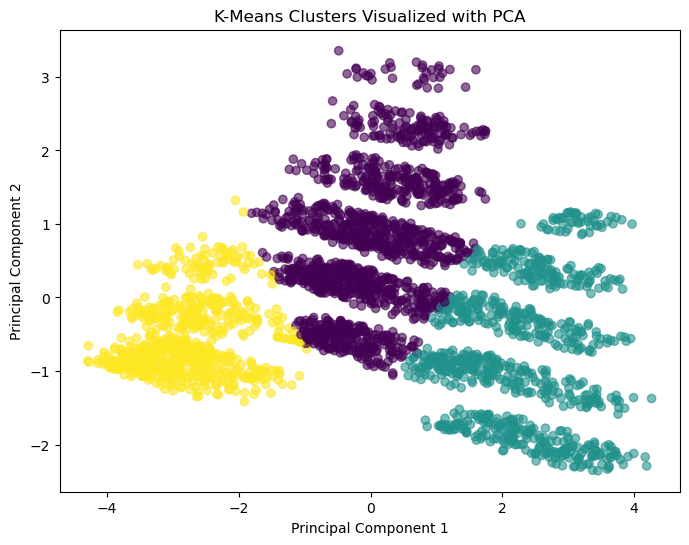

In [17]:
#Visualize K-Means clusters using PCA
plot_df = pca_df.copy()
plot_df['cluster'] = df['kmeans_cluster']

plt.figure(figsize=(8, 6))
plt.scatter(plot_df['PC1'], plot_df['PC2'], c=plot_df['cluster'], alpha=0.6)
plt.title('K-Means Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [18]:
df.groupby('kmeans_cluster_ordered')[
    ['num_ap_courses','stem_courses','humanities_courses','avg_exam_score','score_variance','participation_intensity']
].mean()

,num_ap_courses,stem_courses,humanities_courses,avg_exam_score,score_variance,participation_intensity
kmeans_cluster_ordered,,,,,,
0,1.047686,0.542777,0.504909,2.626957,1.000330,2.761309
1,4.438633,1.642259,2.796374,3.454444,0.644299,15.327873
2,6.483001,5.012896,1.470106,4.263179,0.517279,27.680229


The K-Means clustering model identified three distinct groups of students based on AP participation and performance patterns.

Cluster 0 represents low-participation students. These students take approximately 1 AP course on average (1.05) and have the lowest average exam scores (2.63), along with the highest score variability. This suggests less consistent academic performance and limited engagement with AP coursework.

Cluster 1 represents moderately engaged students. These students take around 4–5 AP courses (4.44) and have average exam scores near 3.45. Their course-taking is more balanced, with a higher proportion of humanities courses, and they demonstrate moderate consistency in performance.

Cluster 2 represents high-intensity students. These students take the most AP courses (6.48) and have the highest average exam scores (4.26). They are more STEM-focused and show relatively low score variability, indicating strong and consistent academic performance.

Overall, the clusters align well with the underlying structure of the synthetic dataset, capturing low, moderate, and high levels of academic engagement.

## 6. Model 2: Hierarchical Clustering

Hierarchical clustering builds clusters by repeatedly merging observations or groups of observations. This project uses Ward linkage because it is commonly used with numeric data and tends to create compact clusters.

A dendrogram will be used to visualize the hierarchical structure, but the final model will assign students to a selected number of clusters.

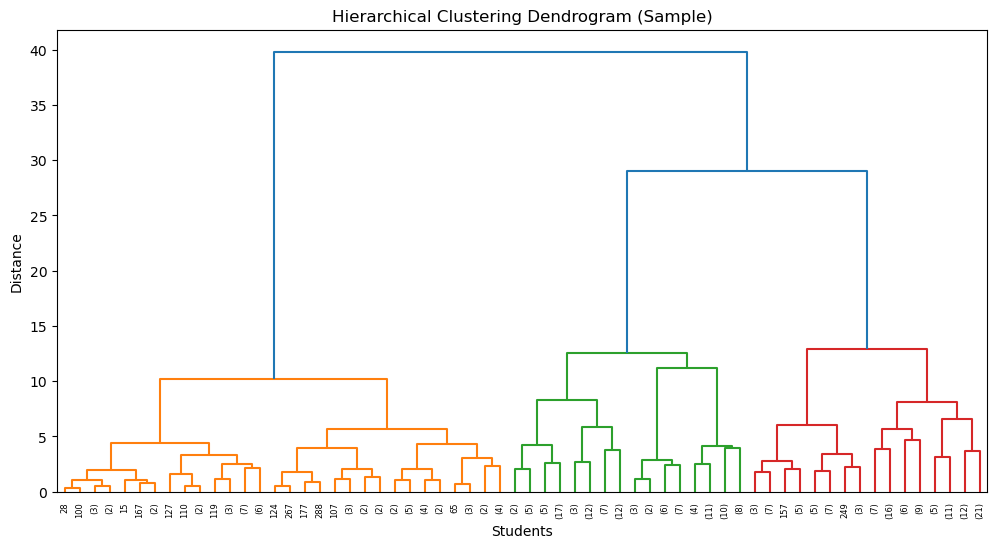

In [19]:
# Create dendrogram sample

sample_size = 300
sample_indices = np.random.choice(range(X_scaled.shape[0]), size=sample_size, replace=False)
X_sample = X_scaled[sample_indices]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (Sample)')
plt.xlabel('Students')
plt.ylabel('Distance')
plt.show()

The dendrogram from hierarchical clustering suggests the presence of three primary clusters. This is indicated by a noticeable increase in linkage distance when merging from three clusters to two, suggesting that combining these groups results in a loss of meaningful structure.

At lower distance thresholds, the data separates into smaller subgroups, but these are less distinct and likely represent minor variations within broader student categories.

The identification of three clusters aligns with the results from the K-Means model, providing additional support for this cluster structure in the data.

In [20]:
#Tune hierarchical clustering across cluster counts

hierarchical_results = []

for k in range(2, 7):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    
    hierarchical_results.append({
        'model': 'Hierarchical',
        'k': k,
        'silhouette_score': sil,
        'davies_bouldin_score': db,
        'calinski_harabasz_score': ch
    })

hierarchical_results_df = pd.DataFrame(hierarchical_results)
hierarchical_results_df

,model,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,Hierarchical,2,0.394143,0.864455,2046.961785
1,Hierarchical,3,0.356290,1.035816,2500.853789
2,Hierarchical,4,0.293354,1.196904,2139.809786
3,Hierarchical,5,0.257047,1.395418,1858.043816
4,Hierarchical,6,0.240562,1.404459,1705.914774


In [21]:
#Fit final hierarchical clustering model

best_hier_k = hierarchical_results_df.sort_values('silhouette_score', ascending=False).iloc[0]['k']
best_hier_k = int(best_hier_k)

hierarchical_final = AgglomerativeClustering(n_clusters=best_hier_k, linkage='ward')
df['hierarchical_cluster'] = hierarchical_final.fit_predict(X_scaled)

best_hier_k

2

In [22]:
# k = 2 (best by silhouette)
hierarchical_k2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
df['hierarchical_cluster_2'] = hierarchical_k2.fit_predict(X_scaled)

# k = 3 (for interpretability comparison)
hierarchical_k3 = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['hierarchical_cluster_3'] = hierarchical_k3.fit_predict(X_scaled)

### Comparing Hierarchical Clustering Solutions (k = 2 vs k = 3)

Although the silhouette score suggested that k = 2 is optimal, a k = 3 solution is also examined to evaluate whether it provides more interpretable and meaningful groupings of students.

In [23]:
feature_cols = [
    'num_ap_courses',
    'stem_courses',
    'humanities_courses',
    'avg_exam_score',
    'score_variance',
    'participation_intensity'
]
# Fit both k = 2 and k = 3 so we can compare the metric-best solution
# with the more interpretable solution.

print("=== Hierarchical Clustering (k = 2) ===")
display(df.groupby('hierarchical_cluster_2')[feature_cols].mean())

print("\n=== Hierarchical Clustering (k = 3) ===")
display(df.groupby('hierarchical_cluster_3')[feature_cols].mean())

=== Hierarchical Clustering (k = 2) ===


,num_ap_courses,stem_courses,humanities_courses,avg_exam_score,score_variance,participation_intensity
hierarchical_cluster_2,,,,,,
0,5.158573,2.870649,2.287924,3.742988,0.602369,19.732536
1,0.947994,0.502229,0.445765,2.605129,1.005478,2.440725



=== Hierarchical Clustering (k = 3) ===


,num_ap_courses,stem_courses,humanities_courses,avg_exam_score,score_variance,participation_intensity
hierarchical_cluster_3,,,,,,
0,4.341499,1.526657,2.814841,3.433453,0.652898,14.919150
1,0.947994,0.502229,0.445765,2.605129,1.005478,2.440725
2,6.366347,4.857295,1.509052,4.200532,0.527678,26.847529


### Final Hierarchical Clustering Interpretation

Hierarchical clustering results were evaluated using both k = 2 and k = 3 cluster solutions.

The k = 2 solution produced the highest silhouette score, indicating a strong separation between two broad groups. 
    This split primarily distinguishes between low-participation students and all other students. 
    While this provides a clear division, it oversimplifies the structure of the data.

The k = 3 solution, although slightly lower in silhouette score, provides a more nuanced 
and interpretable classification. It identifies three distinct groups:

- A low-participation group with minimal AP course-taking and lower exam performance  
- A moderately engaged group with balanced course-taking and mid-range performance  
- A high-intensity group with the highest AP participation and strongest exam outcomes  

These groupings align closely with the results from the K-Means clustering model and reflect the underlying structure of the 
synthetic dataset.

For this reason, the k = 3 solution is selected as the preferred clustering, as it balances model fit with 
interpretability and provides more meaningful insight into student behavior.

## 7. Model 3: DBSCAN

DBSCAN is a density-based clustering method. Unlike K-Means and hierarchical clustering, it does not require specifying the number of clusters in advance. It can also identify noise points.

However, DBSCAN is sensitive to parameter choices, especially `eps` and `min_samples`. This section will document the tuning process.

In [24]:
# Tune DBSCAN parameters

dbscan_results = []

eps_values = np.arange(0.75, 1.06, 0.05)
min_samples_values = [5, 8, 10, 12, 15]

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_pct = n_noise / len(labels)
        
        if n_clusters > 1:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = np.nan
        
        dbscan_results.append({
            'eps': round(eps, 2),
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': noise_pct,
            'silhouette_score': sil
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

# Show reasonable DBSCAN options first
dbscan_results_df[
    (dbscan_results_df['n_clusters'].between(2, 6)) &
    (dbscan_results_df['noise_pct'] < 0.20)
].sort_values('silhouette_score', ascending=False)

,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette_score


In [25]:
# Show all DBSCAN results to understand why the filtered table was empty
dbscan_results_df.sort_values(
    ['eps', 'min_samples']
)

,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette_score
0,0.75,5,17,12,0.004000,0.050003
1,0.75,8,17,21,0.007000,0.049163
2,0.75,10,18,33,0.011000,0.041233
3,0.75,12,17,56,0.018667,0.038806
4,0.75,15,17,97,0.032333,0.037096
5,0.80,5,9,8,0.002667,0.029947
6,0.80,8,9,9,0.003000,0.034810
7,0.80,10,10,17,0.005667,0.027646
8,0.80,12,9,36,0.012000,0.027061
9,0.80,15,8,55,0.018333,0.029543


In [26]:
# Show the highest silhouette scores, even if the cluster counts are not ideal
dbscan_results_df.sort_values(
    'silhouette_score', 
    ascending=False
).head(10)

,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette_score
0,0.75,5,17,12,0.004000,0.050003
1,0.75,8,17,21,0.007000,0.049163
2,0.75,10,18,33,0.011000,0.041233
3,0.75,12,17,56,0.018667,0.038806
4,0.75,15,17,97,0.032333,0.037096
6,0.80,8,9,9,0.003000,0.034810
5,0.80,5,9,8,0.002667,0.029947
9,0.80,15,8,55,0.018333,0.029543
7,0.80,10,10,17,0.005667,0.027646
8,0.80,12,9,36,0.012000,0.027061


In [27]:
#Fit final DBSCAN model based on tuning results

best_dbscan = dbscan_results_df.dropna().sort_values('silhouette_score', ascending=False).iloc[0]

dbscan_final = DBSCAN(
    eps=best_dbscan['eps'],
    min_samples=int(best_dbscan['min_samples'])
)

df['dbscan_cluster'] = dbscan_final.fit_predict(X_scaled)

best_dbscan

eps                  0.750000
min_samples          5.000000
n_clusters          17.000000
n_noise             12.000000
noise_pct            0.004000
silhouette_score     0.050003
Name: 0, dtype: float64

### DBSCAN Interpretation

DBSCAN was evaluated using a range of `eps` and `min_samples` values. The results showed that DBSCAN was not well suited for this dataset.

At lower values of `eps`, DBSCAN produced a large number of small clusters (e.g., 17–18 clusters), indicating that the model was overly sensitive to small variations in the data. As `eps` increased, the number of clusters decreased rapidly, eventually collapsing into a single cluster for larger values of `eps`.

This pattern suggests that the synthetic AP dataset does not contain strong density-based cluster structures with clear low-density separation between groups. Instead, the data is more continuously distributed, which is better suited for methods like K-Means and hierarchical clustering.

A representative DBSCAN model was selected based on the highest available silhouette score from the tuning results. While it identified multiple clusters, these were less interpretable and less stable than those produced by K-Means and hierarchical clustering.

Overall, DBSCAN was less effective for this dataset, highlighting that clustering performance depends on the underlying structure of the data.

## 8. Model 4: Gaussian Mixture Model

Gaussian Mixture Models are probabilistic clustering models. Unlike K-Means, GMM allows clusters to have different shapes and assigns observations based on probabilities.

This section compares models with different numbers of components using BIC and AIC, along with silhouette score.

In [28]:
#Tune GMM components

gmm_results = []

for k in range(2, 7):
    model = GaussianMixture(n_components=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    bic = model.bic(X_scaled)
    aic = model.aic(X_scaled)
    
    gmm_results.append({
        'k': k,
        'silhouette_score': sil,
        'bic': bic,
        'aic': aic
    })

gmm_results_df = pd.DataFrame(gmm_results)
gmm_results_df

,k,silhouette_score,bic,aic
0,2,0.332716,-13551.539491,-13881.889707
1,3,0.278096,-17067.498218,-17566.026726
2,4,0.260173,-18885.086409,-19551.793209
3,5,0.185452,-27049.684676,-27884.569768
4,6,0.140990,-44986.060810,-45989.124194


In [29]:
#Fit final GMM model

best_gmm_k = 3

gmm_final = GaussianMixture(n_components=best_gmm_k, random_state=42)
df['gmm_cluster'] = gmm_final.fit_predict(X_scaled)

In [30]:
df.groupby('gmm_cluster')[feature_cols].mean()

,num_ap_courses,stem_courses,humanities_courses,avg_exam_score,score_variance,participation_intensity
gmm_cluster,,,,,,
0,6.219626,3.943925,2.275701,4.037351,0.560311,25.206234
1,0.944444,0.469970,0.474474,2.582874,1.003358,2.385907
2,3.835238,1.562857,2.272381,3.389554,0.657833,12.958476


### Gaussian Mixture Model (GMM) Interpretation

The Gaussian Mixture Model (GMM) was evaluated across multiple values of k using silhouette score, AIC, and BIC.

The silhouette score suggested that k = 2 provided the best cluster separation, while both AIC and BIC continued to 
improve with larger values of k, favoring more complex models. This indicates a tradeoff between model simplicity 
and model fit.

To balance interpretability and consistency with previous models, a solution with k = 3 clusters was selected. 
This choice aligns with the results from K-Means and hierarchical clustering and reflects the intended structure 
of the synthetic dataset.

The resulting clusters correspond to:

- A low-participation group with minimal AP course-taking and lower exam performance  
- A moderately engaged group with balanced participation and mid-range performance  
- A high-intensity group with higher AP participation and stronger exam outcomes  

These results reinforce the conclusion that the dataset contains three primary student profiles. 
While GMM provides a probabilistic clustering framework, it did not produce substantially different groupings 
from the other methods in this case.

## 9. Model Comparison

In [31]:
comparison_rows = [
    {"Model": "K-Means", "Best k": best_k, "Strength": "Clear, interpretable clusters"},
    {"Model": "Hierarchical", "Best k": f"{best_hier_k} by silhouette; 3 used for interpretation", "Strength": "Confirms structure"},
    {"Model": "DBSCAN", "Best k": "N/A", "Strength": "Shows density mismatch"},
    {"Model": "GMM", "Best k": best_gmm_k, "Strength": "Probabilistic confirmation"}
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model,Best k,Strength
0,K-Means,3,"Clear, interpretable clusters"
1,Hierarchical,2 by silhouette; 3 used for interpretation,Confirms structure
2,DBSCAN,N/A,Shows density mismatch
3,GMM,3,Probabilistic confirmation


## Model Comparison

This project compared four clustering approaches: K-Means, hierarchical clustering, DBSCAN, and Gaussian Mixture Models (GMM). 
Each method was evaluated using a combination of quantitative metrics (e.g., silhouette score) and qualitative 
interpretation of the resulting clusters.

### K-Means
K-Means produced a clear and interpretable solution with k = 3 clusters. These clusters represented low, moderate, 
and high levels of AP participation and performance. The model provided strong separation and was easy to interpret, 
making it one of the most effective approaches for this dataset.

### Hierarchical Clustering
Hierarchical clustering produced a slightly different result depending on the evaluation metric. While the silhouette 
score suggested k = 2, the dendrogram and cluster interpretation supported a k = 3 solution. 
The k = 3 clusters aligned closely with those from K-Means, reinforcing the presence of three meaningful student groups.

### DBSCAN
DBSCAN was less effective for this dataset. With smaller values of `eps`, the model produced many small clusters, 
while larger values caused the data to collapse into a single cluster. This indicates that the dataset does not contain 
strong density-based cluster structures. As a result, DBSCAN did not produce stable or interpretable groupings.

### Gaussian Mixture Model (GMM)
GMM provided results similar to K-Means, identifying comparable cluster structures. While AIC and BIC favored more 
complex models, a k = 3 solution was selected to balance model fit and interpretability. The clusters again reflected low, 
moderate, and high levels of student engagement.

### Overall Comparison
Across methods, K-Means, hierarchical clustering, and GMM consistently identified three primary student groups. 
This consistency suggests that the underlying structure of the synthetic dataset is stable and well-defined.

DBSCAN, in contrast, struggled to identify meaningful clusters due to the continuous nature of the data. This highlights an
important insight: the effectiveness of a clustering method depends on how well its assumptions align with the structure of 
the data.

Overall, K-Means and hierarchical clustering were the most effective methods for this dataset, with GMM providing 
additional confirmation of the results.

## 10. Cluster Interpretation

This section describes what each cluster represents in plain language.

For each method, the cluster profiles will be summarized using the average values of the original features. This is important because a cluster is only useful if it can be interpreted meaningfully.

In [32]:
# Summarize cluster profiles

kmeans_profiles = df.groupby('kmeans_cluster')[feature_cols].mean()
kmeans_profiles

,num_ap_courses,stem_courses,humanities_courses,avg_exam_score,score_variance,participation_intensity
kmeans_cluster,,,,,,
0,4.438633,1.642259,2.796374,3.454444,0.644299,15.327873
1,6.483001,5.012896,1.470106,4.263179,0.517279,27.680229
2,1.047686,0.542777,0.504909,2.626957,1.000330,2.761309


In [33]:
#Compare cluster sizes

df['kmeans_cluster'].value_counts().sort_index()

kmeans_cluster
0    1434
1     853
2     713
Name: count, dtype: int64

### Interpretation Notes

Cluster 0 appears to represent moderate participation, humanities-leaning student. These students take a moderate number of AP courses (4.4), with more courses in humanities than STEM. Their average exam scores are solid (3.45), with moderate variability, suggesting consistent but not extreme performance.

Cluster 1 represents high-intensity, high-performing STEM-focused students. These students take the most AP courses (6.5), with a strong emphasis on STEM (5 courses). They have the highest average exam scores (~4.26) and relatively low score variability, indicating both high achievement and consistency.

Cluster 2 represents low participation, lower-performing students. These students take very few AP courses (1.0) across both STEM and humanities. Their average exam scores are the lowest (2.63), and they show higher variability, suggesting less consistent performance.

In terms of size, Cluster 0 is the largest group (1434 students), followed by Cluster 1 (853 students) and Cluster 2 (713 students). This suggests that most students fall into a moderate participation profile, while smaller groups represent high-achieving and low-participation extremes.


## 11. Bias and Fairness Considerations

Because this project uses synthetic data, it does not include actual student records or personally identifiable information, which helps protect student privacy.

However, synthetic data can still introduce bias because it reflects the assumptions used to generate it. For example, features such as participation intensity and average exam score may implicitly assume that taking more AP courses leads to higher performance, which may not reflect all real student experiences. As a result, the identified clusters may reinforce simplified interpretations of student ability or academic pathways.

To address this risk, this project:

* Clearly documents the assumptions used to generate the data
* Includes multiple student profiles rather than relying on a single definition of success
* Avoids using demographic variables, while recognizing that structural inequities may still be indirectly reflected in course-taking patterns
* Interprets clusters as patterns in the data rather than fixed student identities

## 12. Overfitting Prevention and Generalization

Although this is an unsupervised learning project, generalization remains important. A clustering method may appear effective on one dataset but fail to produce stable or meaningful patterns in another.

This project addresses generalization by:

* Comparing results across multiple clustering methods, including K-Means, Hierarchical Clustering, and Gaussian Mixture Models
* Evaluating cluster quality using metrics such as silhouette score
* Avoiding conclusions based solely on PCA visualizations
* Documenting key parameter choices, particularly for DBSCAN and GMM

The consistency of a three-cluster solution across multiple methods suggests that the identified student groupings are reasonably stable within the simulated dataset.

In [34]:
#Optional stability test with multiple random seeds

stability_results = []

for seed in [1, 10, 25, 42, 100]:
    model = KMeans(n_clusters=best_k, random_state=seed, n_init=10)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)

    stability_results.append({
        'seed': seed,
        'model': 'K-Means',
        'silhouette_score': sil
    })

stability_df = pd.DataFrame(stability_results)
stability_df

,seed,model,silhouette_score
0,1,K-Means,0.368485
1,10,K-Means,0.368485
2,25,K-Means,0.368485
3,42,K-Means,0.368485
4,100,K-Means,0.368485


### Stability Analysis Across Random Seeds

To evaluate the robustness of the K-Means clustering solution, the model was run multiple times using different random seeds. This helps determine whether the clustering results are sensitive to initialization or remain consistent across runs.

The silhouette score remained constant (0.3685) across all tested seeds (1, 10, 25, 42, 100). 
This indicates that the clustering solution is highly stable and not dependent on random initialization.

This stability suggests that:

* The identified cluster structure is consistent within the dataset
* The choice of ( k = 3 ) produces a reliable partition of the data
* The results are unlikely to change meaningfully with different random starting points

Overall, this provides additional confidence that the clustering solution reflects underlying patterns in the data rather than randomness in the algorithm.



## 13. Reflection

This project showed how different unsupervised learning methods can produce different classifications even when applied to the same dataset. One key challenge was evaluating model quality without true labels. For that reason, the project used a combination of quantitative metrics, visualizations, and interpretability.

Important decisions included using synthetic data to protect privacy, standardizing features before clustering, and using PCA only for visualization. DBSCAN and GMM required additional attention because their results can be sensitive to parameter choices.

The main takeaway is that clustering is not only a technical process. The best model is not necessarily the one with the highest metric score. It also needs to produce groups that are stable, understandable, and useful for the research question.

## 14. Conclusion

This project compared several unsupervised learning methods for classifying students using synthetic AP data, including K-Means, Hierarchical Clustering, DBSCAN, and Gaussian Mixture Models.

Across methods, a three-cluster solution consistently emerged as the most meaningful and interpretable structure. K-Means and GMM produced the clearest and most stable groupings, while Hierarchical Clustering supported a similar structure through the dendrogram. DBSCAN was less effective due to differences in density across the data.

The final clusters represent distinct student profiles:

* High-intensity, high-performing STEM-focused students
* Moderate participation, humanities-leaning students
* Low participation, lower-performing students

These groupings highlight that student differences are not just about performance, but also about patterns of engagement and course-taking behavior.

Overall, this project demonstrates that clustering can be a useful tool for identifying meaningful patterns in student data, especially when results are evaluated using a combination of metrics, visualization, and interpretability.


## 15. References

- Scikit-learn documentation for clustering models
- Course materials from AAI201 Machine Learning